# Libraries

In [ ]:
### Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load the data

In [ ]:
# Load the dataset
retention = pd.read_csv("HighRegDiscrete.csv")


In [ ]:
retention

,id,subscription,year,defect
0,1,high,1,1
1,2,high,1,1
2,3,high,1,1
3,4,high,1,1
4,5,high,1,1
...,...,...,...,...
8279,2000,regular,3,0
8280,2000,regular,4,0
8281,2000,regular,5,0
8282,2000,regular,6,0


In [ ]:
retention.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8284 entries, 0 to 8283
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            8284 non-null   int64 
 1   subscription  8284 non-null   object
 2   year          8284 non-null   int64 
 3   defect        8284 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 259.0+ KB


In [ ]:
# Summary of subscription types
print(retention['subscription'].value_counts())

subscription
high       4919
regular    3365
Name: count, dtype: int64


# Aggregate Data: Plot Survival and Hazard Rates

In [ ]:
# Group data by subscription type and year
data = retention.groupby(['subscription', 'year']).agg(
    defect=('defect', 'sum'),
    customers=('defect', 'count')
).reset_index()

In [ ]:
data

,subscription,year,defect,customers
0,high,1,131,999
1,high,2,126,868
2,high,3,90,742
3,high,4,60,652
4,high,5,42,592
5,high,6,34,550
6,high,7,26,516
7,regular,1,369,1001
8,regular,2,163,632
9,regular,3,86,469


In [ ]:
# Calculate hazard rate: defect/customers
data['hazard_rate'] = data['defect'] / data['customers']

# Calculate cumulative defect (cumulative sum of defects by subscription)
data['cum_defect'] = data.groupby('subscription')['defect'].cumsum()

# Calculate survival rate: (customers - defect) / max(customers) per subscription
data['survival_rate'] = (data['customers'] - data['defect']) / data.groupby('subscription')['customers'].transform('max')

# Display the resulting aggregated data
data

,subscription,year,defect,customers,hazard_rate,cum_defect,survival_rate
0,high,1,131,999,0.131131,131,0.868869
1,high,2,126,868,0.145161,257,0.742743
2,high,3,90,742,0.121294,347,0.652653
3,high,4,60,652,0.092025,407,0.592593
4,high,5,42,592,0.070946,449,0.550551
5,high,6,34,550,0.061818,483,0.516517
6,high,7,26,516,0.050388,509,0.490490
7,regular,1,369,1001,0.368631,369,0.631369
8,regular,2,163,632,0.257911,532,0.468531
9,regular,3,86,469,0.183369,618,0.382617


## Plot the Survival rate and hazard rate

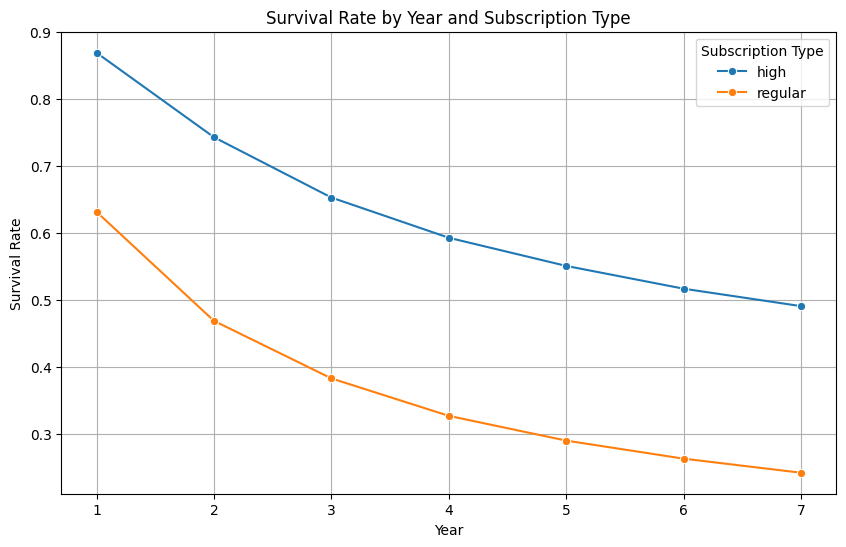

In [ ]:
# Plot survival rate by year for each subscription type
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=data,
    x='year',
    y='survival_rate',
    hue='subscription',
    marker='o'
)

plt.title("Survival Rate by Year and Subscription Type")
plt.xlabel("Year")
plt.ylabel("Survival Rate")
plt.grid(True)
plt.legend(title='Subscription Type')
plt.show()


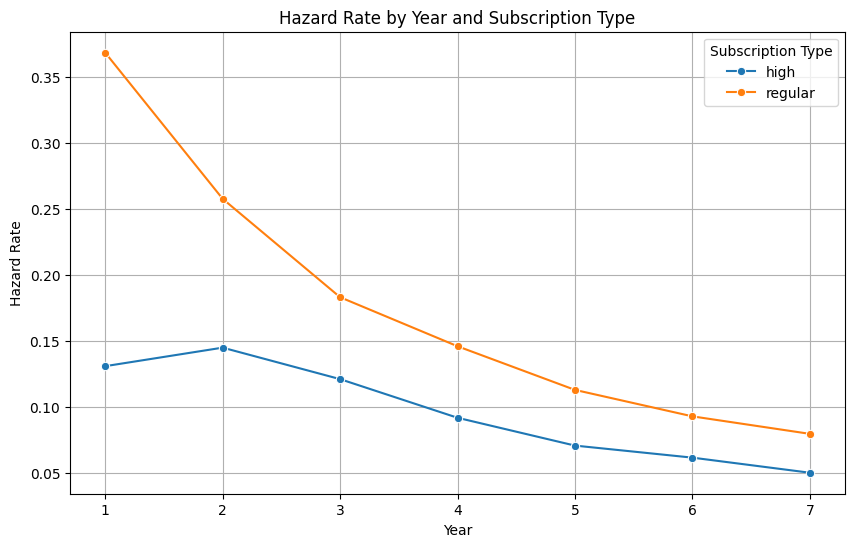

In [ ]:
# Plot hazard rate by year for each subscription type
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=data,
    x='year',
    y='hazard_rate',
    hue='subscription',
    marker='o'
)

plt.title("Hazard Rate by Year and Subscription Type")
plt.xlabel("Year")
plt.ylabel("Hazard Rate")
plt.grid(True)
plt.legend(title='Subscription Type')
plt.show()


# Logistic Regression Model

This is using original dataset retention to predict individual level defect/churn

In [ ]:
retention

,id,subscription,year,defect
0,1,high,1,1
1,2,high,1,1
2,3,high,1,1
3,4,high,1,1
4,5,high,1,1
...,...,...,...,...
8279,2000,regular,3,0
8280,2000,regular,4,0
8281,2000,regular,5,0
8282,2000,regular,6,0


In [ ]:
# Fit a logistic regression model
# Using categorical predictors: 'year' and 'subscription'
mod1 = smf.logit('defect ~ C(year) + C(subscription)', data=retention).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.398668
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 defect   No. Observations:                 8284
Model:                          Logit   Df Residuals:                     8276
Method:                           MLE   Df Model:                            7
Date:                Thu, 06 Mar 2025   Pseudo R-squ.:                 0.06851
Time:                        22:29:47   Log-Likelihood:                -3302.6
converged:                       True   LL-Null:                       -3545.5
Covariance Type:            nonrobust   LLR p-value:                8.933e-101
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -1.5601      0.065    -23.979      0.000      

In [ ]:
# Predict hazard rate for the aggregated data
retention['hazard_rate_pred'] = mod1.predict(retention)

retention

,id,subscription,year,defect,hazard_rate_pred
0,1,high,1,1,0.173627
1,2,high,1,1,0.173627
2,3,high,1,1,0.173627
3,4,high,1,1,0.173627
4,5,high,1,1,0.173627
...,...,...,...,...,...
8279,2000,regular,3,0,0.210869
8280,2000,regular,4,0,0.166801
8281,2000,regular,5,0,0.130702
8282,2000,regular,6,0,0.111962


### Applying the Model to Predict Hazard Rate

When we apply the model to the retention dataset and predict the hazard rate for individuals, we find that all individuals with the same year and subscription values receive the same predicted hazard_rate_pred.

This result is expected because our logistic model includes only year and subscription as independent variables. Consequently, individuals with identical values for these variables will have identical predictions.

In contrast, if we use a different model—such as your homework Case 3, which incorporates additional individual-level variables—the predicted hazard_rate_pred would exhibit more variation, providing a more granular view of individual differences.

# Model based hazard rate and survival rate

## Step 1: Aggregating Predicted Hazard Rates

The retention dataset contains individual-level predictions for hazard rates (`hazard_rate_pred`), indicating the likelihood of defection (churn) for each individual.

To compare these predictions with actual churn data, we group the dataset by subscription and year to compute the average predicted hazard rate.

This aggregated dataset (`retention_pred`) is then merged with the `data` dataset, which contains actual hazard rates (`hazard_rate`) and survival rates.


In [ ]:
# Group the dataset by 'subscription' and 'year' to compute the average predicted hazard rate
retention_pred = retention.groupby(['subscription', 'year']).agg(
    hazard_rate_pred=('hazard_rate_pred', 'mean')  # Compute mean hazard rate per group
).reset_index()

retention_pred


,subscription,year,hazard_rate_pred
0,high,1,0.173627
1,high,2,0.137423
2,high,3,0.103911
3,high,4,0.079931
4,high,5,0.061251
5,high,6,0.051874
6,high,7,0.043128
7,regular,1,0.326220
8,regular,2,0.268539
9,regular,3,0.210869


In [ ]:
data

,subscription,year,defect,customers,hazard_rate,cum_defect,survival_rate
0,high,1,131,999,0.131131,131,0.868869
1,high,2,126,868,0.145161,257,0.742743
2,high,3,90,742,0.121294,347,0.652653
3,high,4,60,652,0.092025,407,0.592593
4,high,5,42,592,0.070946,449,0.550551
5,high,6,34,550,0.061818,483,0.516517
6,high,7,26,516,0.050388,509,0.490490
7,regular,1,369,1001,0.368631,369,0.631369
8,regular,2,163,632,0.257911,532,0.468531
9,regular,3,86,469,0.183369,618,0.382617


In [ ]:
# Merge retention_pred with the data dataset on 'subscription' and 'year'
retention_agg = pd.merge(data, retention_pred, on=['subscription', 'year'])

retention_agg

,subscription,year,defect,customers,hazard_rate,cum_defect,survival_rate,hazard_rate_pred
0,high,1,131,999,0.131131,131,0.868869,0.173627
1,high,2,126,868,0.145161,257,0.742743,0.137423
2,high,3,90,742,0.121294,347,0.652653,0.103911
3,high,4,60,652,0.092025,407,0.592593,0.079931
4,high,5,42,592,0.070946,449,0.550551,0.061251
5,high,6,34,550,0.061818,483,0.516517,0.051874
6,high,7,26,516,0.050388,509,0.490490,0.043128
7,regular,1,369,1001,0.368631,369,0.631369,0.326220
8,regular,2,163,632,0.257911,532,0.468531,0.268539
9,regular,3,86,469,0.183369,618,0.382617,0.210869


## **Step 2: Plotting Hazard Rate Comparison**




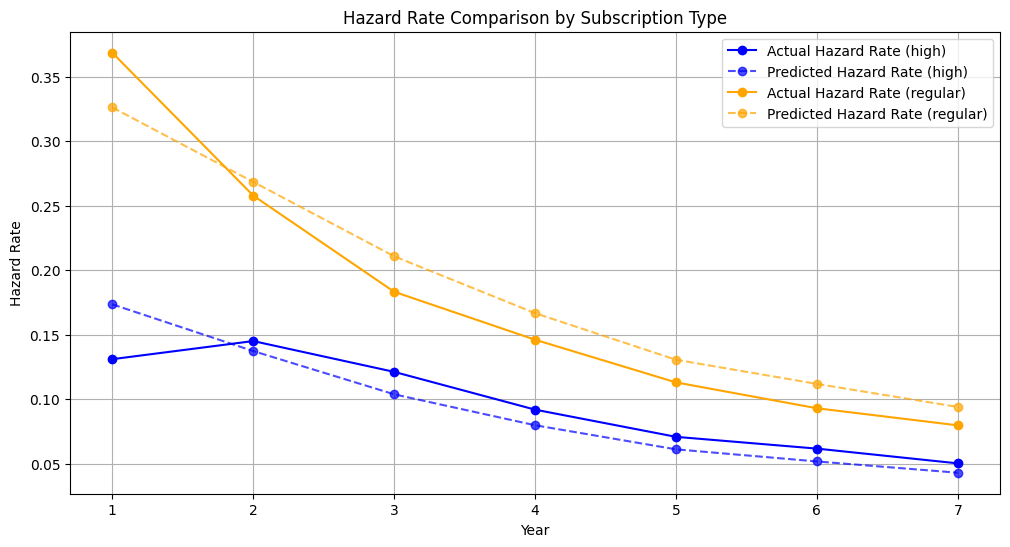

In [ ]:
# Define colors for better visibility
colors = {'high': 'blue', 'regular': 'orange'}

# Create the plot
plt.figure(figsize=(12, 6))

for subscription in ['high', 'regular']:
    subset = retention_agg[retention_agg['subscription'] == subscription]

    # Plot actual hazard rate
    plt.plot(subset['year'], subset['hazard_rate'], 'o-',
             label=f"Actual Hazard Rate ({subscription})",
             color=colors[subscription])

    # Plot predicted hazard rate
    plt.plot(subset['year'], subset['hazard_rate_pred'], 'o--',
             label=f"Predicted Hazard Rate ({subscription})",
             color=colors[subscription], alpha=0.7)  # Slight transparency for better differentiation

# Customize plot
plt.title("Hazard Rate Comparison by Subscription Type")
plt.xlabel("Year")
plt.ylabel("Hazard Rate")
plt.legend()
plt.grid(True)  # Add grid for better readability
plt.show()

## **Step 3: Computing and Plotting the Survival Function**
### **1. Initializing `survival_rate_pred`**
- Starts at **1.0**, assuming that **all customers are retained** at time `year = 1`.

### **2. Recursive Computation of Survival Rate**
- The predicted survival rate at time `t` is updated based on the **previous survival rate** and the **predicted hazard rate** using the formula:

$S(t) = S(t-1) \times (1 - \text{hazard rate pred}(t))$

- This ensures that the **survival rate decreases over time** as more individuals churn.

### **3. Plotting Survival Rate**
- The **actual survival rate (`survival_rate`)** and the **model-based survival rate (`survival_rate_pred`)** are compared over **time (`year`)** for each **subscription type** (`high` and `regular`).

In [ ]:
# Initialize a new column for model-based survival function
retention_agg['survival_rate_pred'] = 1.0


In [ ]:
# Compute survival function iteratively for each subscription type
for sub in retention_agg['subscription'].unique():
    sub_df = retention_agg[retention_agg['subscription'] == sub].copy()

    # First survival rate
    sub_df.loc[sub_df.index[0], 'survival_rate_pred'] = 1 - sub_df.iloc[0]['hazard_rate_pred']

    # Compute recursively for subsequent time periods
    for i in range(1, len(sub_df)):
        sub_df.loc[sub_df.index[i], 'survival_rate_pred'] = (
            sub_df.loc[sub_df.index[i - 1], 'survival_rate_pred'] *
            (1 - sub_df.loc[sub_df.index[i], 'hazard_rate_pred'])
        )

    # Assign back to the main dataframe
    retention_agg.loc[retention_agg['subscription'] == sub, 'survival_rate_pred'] = sub_df['survival_rate_pred']


In [ ]:
retention_agg

,subscription,year,defect,customers,hazard_rate,cum_defect,survival_rate,hazard_rate_pred,survival_rate_pred
0,high,1,131,999,0.131131,131,0.868869,0.173627,0.826373
1,high,2,126,868,0.145161,257,0.742743,0.137423,0.712810
2,high,3,90,742,0.121294,347,0.652653,0.103911,0.638741
3,high,4,60,652,0.092025,407,0.592593,0.079931,0.587685
4,high,5,42,592,0.070946,449,0.550551,0.061251,0.551689
5,high,6,34,550,0.061818,483,0.516517,0.051874,0.523071
6,high,7,26,516,0.050388,509,0.490490,0.043128,0.500512
7,regular,1,369,1001,0.368631,369,0.631369,0.326220,0.673780
8,regular,2,163,632,0.257911,532,0.468531,0.268539,0.492844
9,regular,3,86,469,0.183369,618,0.382617,0.210869,0.388918


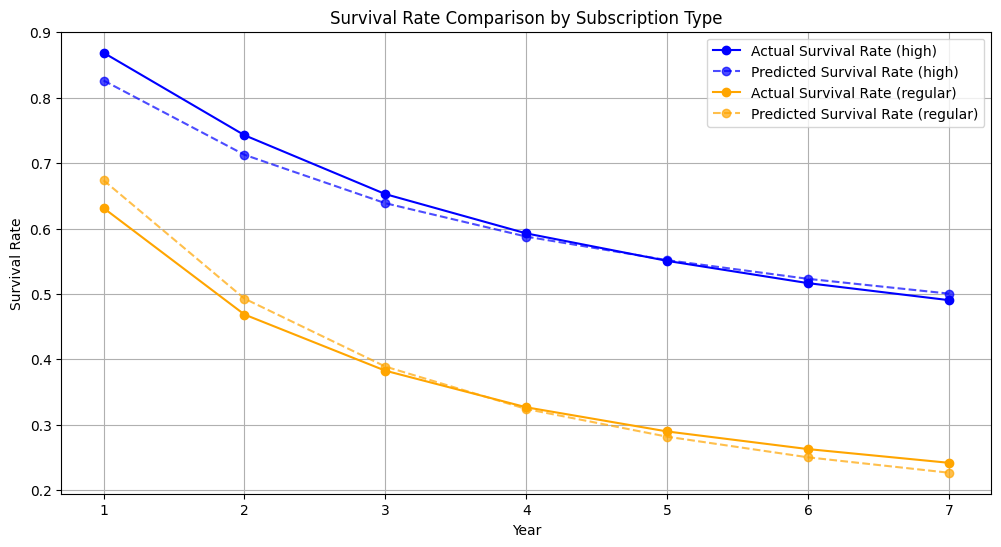

In [ ]:
# Define colors for better visibility
colors = {'high': 'blue', 'regular': 'orange'}

# Create the plot
plt.figure(figsize=(12, 6))

for sub in ["high", "regular"]:
    subset = retention_agg[retention_agg['subscription'] == sub]

    # Plot actual survival rate
    plt.plot(subset['year'], subset['survival_rate'], 'o-',
             label=f"Actual Survival Rate ({sub})",
             color=colors[sub])

    # Plot predicted survival rate
    plt.plot(subset['year'], subset['survival_rate_pred'], 'o--',
             label=f"Predicted Survival Rate ({sub})",
             color=colors[sub], alpha=0.7)  # Slight transparency for better differentiation

# Customize plot
plt.title("Survival Rate Comparison by Subscription Type")
plt.xlabel("Year")
plt.ylabel("Survival Rate")
plt.legend()
plt.grid(True)  # Add grid for better readability
plt.show()
